### FASE 3. Análisis Exploratorio de Datos (EDA)

**Proyecto:** Análisis Exploratorio de Datos — Ingresos totales por ventas a clientes de un comercio.

**Objetivo de esta fase:**
Comprender el comportamiento de los datos mediante estadísticas descriptivas y visualizaciones, identificando patrones, relaciones entre variables y, especialmente, qué factores se asocian a que un cliente (variable `ìd_cliente`) que realiza una compra (variable `order_id`).

**Punto de partida:** `02_datos_limpios.csv` (52.000 filas × 39 columnas), resultado de la Fase 2.

**Flujo que seguiremos:**
1. Recordatorio Pre-EDA.
2. Identificar variables categóricas y numéricas.
3. Análisis univariante (categóricas y numéricas).
4. Análisis bivariante — relación con la variable objetivo `y`.
5. Relación entre variables numéricas y correlaciones globales.
6. Evolución temporal.
7. Preguntas de negocio.
8. Conclusiones de la fase.


In [1]:
# Libreria de Tratamiento de Datos
import pandas as pd
import numpy as np
from IPython.display import display

# Visualizaciones
import matplotlib.pyplot as plt
import seaborn as sns

# Exploracion de Archivos de soporte
import sys
sys.path.append('../') # para que busque en carpeta src 
from src import sp_eda as se

# Para que se muestren todas las columnas al imspeccionar los DataFrames
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 2000)
pd.set_option('display.expand_frame_repr', False)
pd.set_option('display.max_columns',None)

In [2]:
df = pd.read_csv(
    "../data/processed/02_datos_limpios.csv",
    parse_dates=['fecha_pedido', 'fecha_lanzamiento', 'fecha_registro']
)

#### EXPLORACION INICAL

In [3]:
se.exploracion(df)

PRIMERAS COLUMNAS


,27119,12450,1242
order_id,27120,12451,1243
id_cliente,ecc12dc1-956a-40d0-b9e6-a7981accd8e7,22f64527-4182-4c4e-8128-d3ef73178957,224e6215-06ff-4517-a3c3-6f6c45edbe7d
product_id,P0056,P0033,P0068
fecha_pedido,2024-09-16 00:00:00,2022-03-02 00:00:00,2022-12-01 00:00:00
cantidad,2,1,1
precio_unitario,31.63,133.63,41.93
descuento,0.1,0.0,0.0
importe_total,56.94,133.63,41.93
metodo_pago,contrareembolso,tarjeta de debito,tarjeta de credito
envio_gratis,no,si,si


::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::
INFORMACIÓN BÁSICA
<class 'pandas.DataFrame'>
RangeIndex: 52000 entries, 0 to 51999
Data columns (total 39 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   order_id                  52000 non-null  int64         
 1   id_cliente                52000 non-null  str           
 2   product_id                52000 non-null  str           
 3   fecha_pedido              52000 non-null  datetime64[us]
 4   cantidad                  52000 non-null  int64         
 5   precio_unitario           52000 non-null  float64       
 6   descuento                 52000 non-null  float64       
 7   importe_total             52000 non-null  float64       
 8   metodo_pago               52000 non-null  str           
 9   envio_gratis              52000 non-null  str           
 10  calificacion              52000 n

None

::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::
ESTADISTICOS


...

::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::
TAMAÑO DATAFRAME
(52000, 39)
::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::
NULOS


fecha_registro    253
dtype: int64

::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::
PORCENTAJE DE NULOS


fecha_registro    0.49
dtype: float64

::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::
DUPLICADOS
0


##### COMPROBACION VALORES CLAVES

In [4]:
valores_claves=['order_id','id_cliente']

In [5]:
se.comprobar_claves(df,valores_claves)

Valores claves:
order_id: 0 duplicados
order_id: 52000 unicos
Valores claves:
id_cliente: 44013 duplicados
id_cliente: 7987 unicos


##### CREAR TABLA CLIENTES

In [6]:
clientes = df.groupby('id_cliente').agg(
    n_pedidos=('order_id', 'count'),
    gasto_total=('importe_total', 'sum'),
    edad=('edad', 'first'),
    ciudad=('ciudad', 'first'),
    segmento_cliente=('segmento_cliente', 'first'),
    ingresos_anuales=('ingresos_anuales', 'first')
    ).reset_index()

clientes["ticket_medio"] = (
    clientes["gasto_total"] / clientes["n_pedidos"]
)

clientes

,id_cliente,n_pedidos,gasto_total,edad,ciudad,segmento_cliente,ingresos_anuales,ticket_medio
0,00047a8c-eaed-4e09-a302-4081b07e37f9,6,582.25,44.0,barcelona,corporativo,41626,97.041667
1,0005530b-bb59-4862-9ed1-9ba4b57e4b95,8,714.03,64.0,granada,recurrente,64957,89.253750
2,000c848f-a5fc-40a5-a3ba-3de5a7e12089,1,9.49,40.0,sevilla,nuevo,37981,9.490000
3,0013343e-3a60-417d-bad5-88780f5a83a1,4,520.32,34.0,murcia,corporativo,61224,130.080000
4,0030dae9-1d2a-4aaf-ba17-c19d34228fbc,3,193.17,48.0,vigo,recurrente,24208,64.390000
...,...,...,...,...,...,...,...,...
7982,ffe3fcfa-07c0-42c4-b97c-52ab6efac87a,1,110.87,22.0,vigo,nuevo,72177,110.870000
7983,ffe5e4a4-9512-4bbd-98f9-75a00a28f4ce,5,648.41,31.0,zaragoza,nuevo,38826,129.682000
7984,ffea67ee-8438-441c-b8a0-5c0ff886b034,3,175.72,47.0,sevilla,nuevo,35518,58.573333
7985,fff01d47-aae0-4ce5-847d-aea0a915c59d,9,546.42,35.0,malaga,recurrente,30258,60.713333


##### EDA PRELIMINAR

VARIABLES NUMERICAS:

 Index(['order_id', 'cantidad', 'precio_unitario', 'descuento', 'importe_total', 'calificacion', 'año_ventas', 'costo_unitario', 'precio_lista', 'peso_kg', 'stock_disponible', 'rating_promedio_producto', 'edad', 'ingresos_anuales', 'latitude', 'longitude', 'visitas_web_mes', 'precio_unitario_wz', 'importe_total_wz'], dtype='str')

VARIABLES CATEGORICAS:

 Index(['id_cliente', 'product_id', 'metodo_pago', 'envio_gratis', 'devuelto', 'canal', 'categoria_producto', 'nombre_producto', 'marca', 'proveedor', 'estado_civil', 'nivel_educativo', 'tiene_hijos', 'adolescentes_en_casa', 'ciudad', 'region', 'segmento_cliente'], dtype='str')

VARIABLES DATETIME(FECHA):

 Index(['fecha_pedido', 'fecha_lanzamiento', 'fecha_registro'], dtype='str')

========== ESTADÍSTICAS BÁSICAS ==========

VARIABLES NUMERICAS:
                            count      mean       std       min       25%       50%       75%        max
order_id                  52000.0  26000.50  15011.25      1.00  

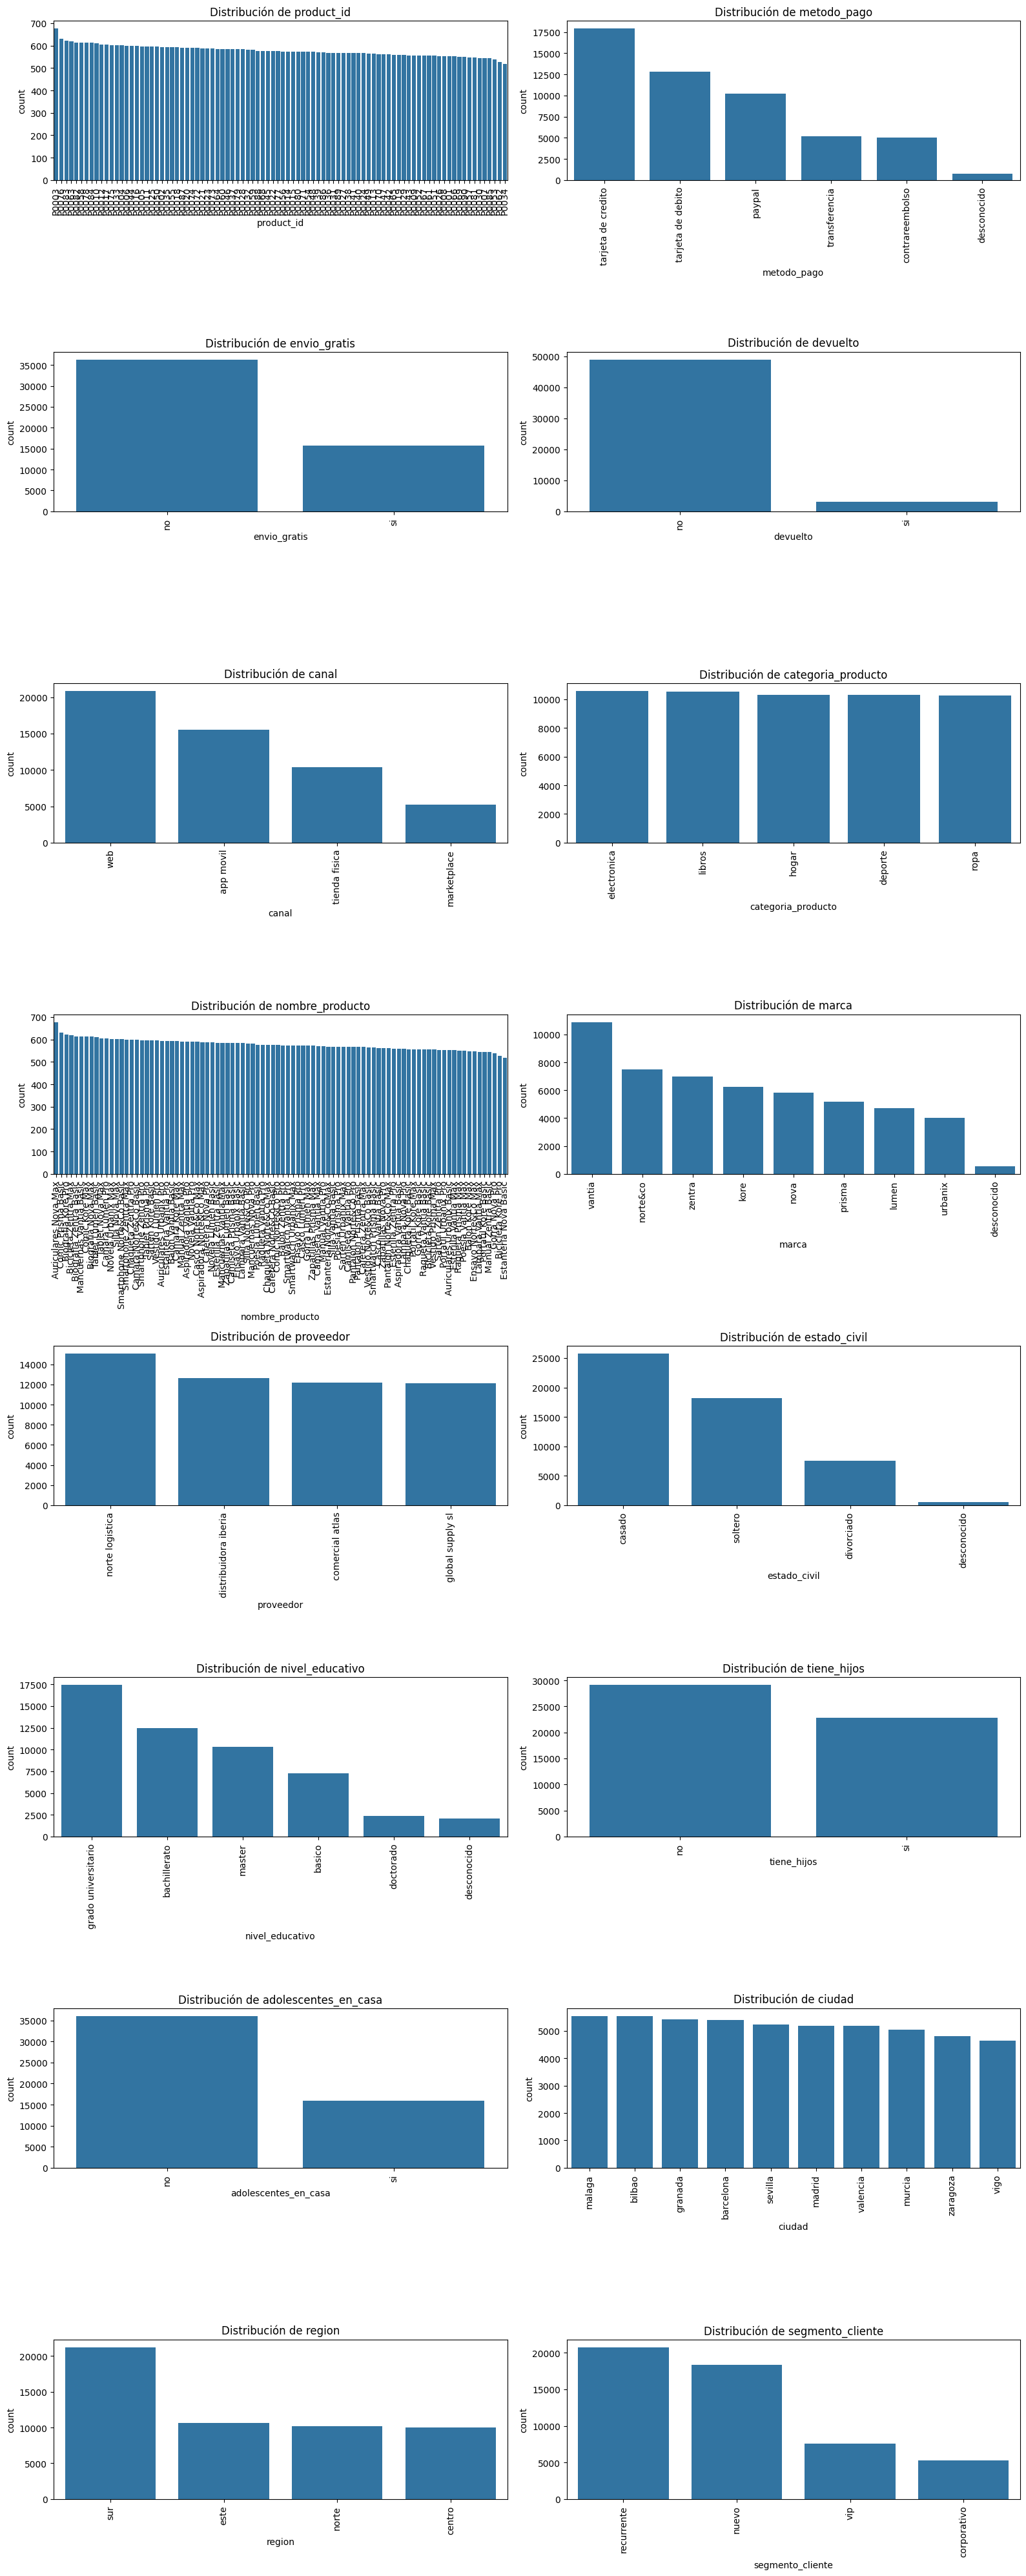


============== HISTOGRAMAS ==============
(REPRESENTACION DE UNIVARIABLES NUMERICAS):


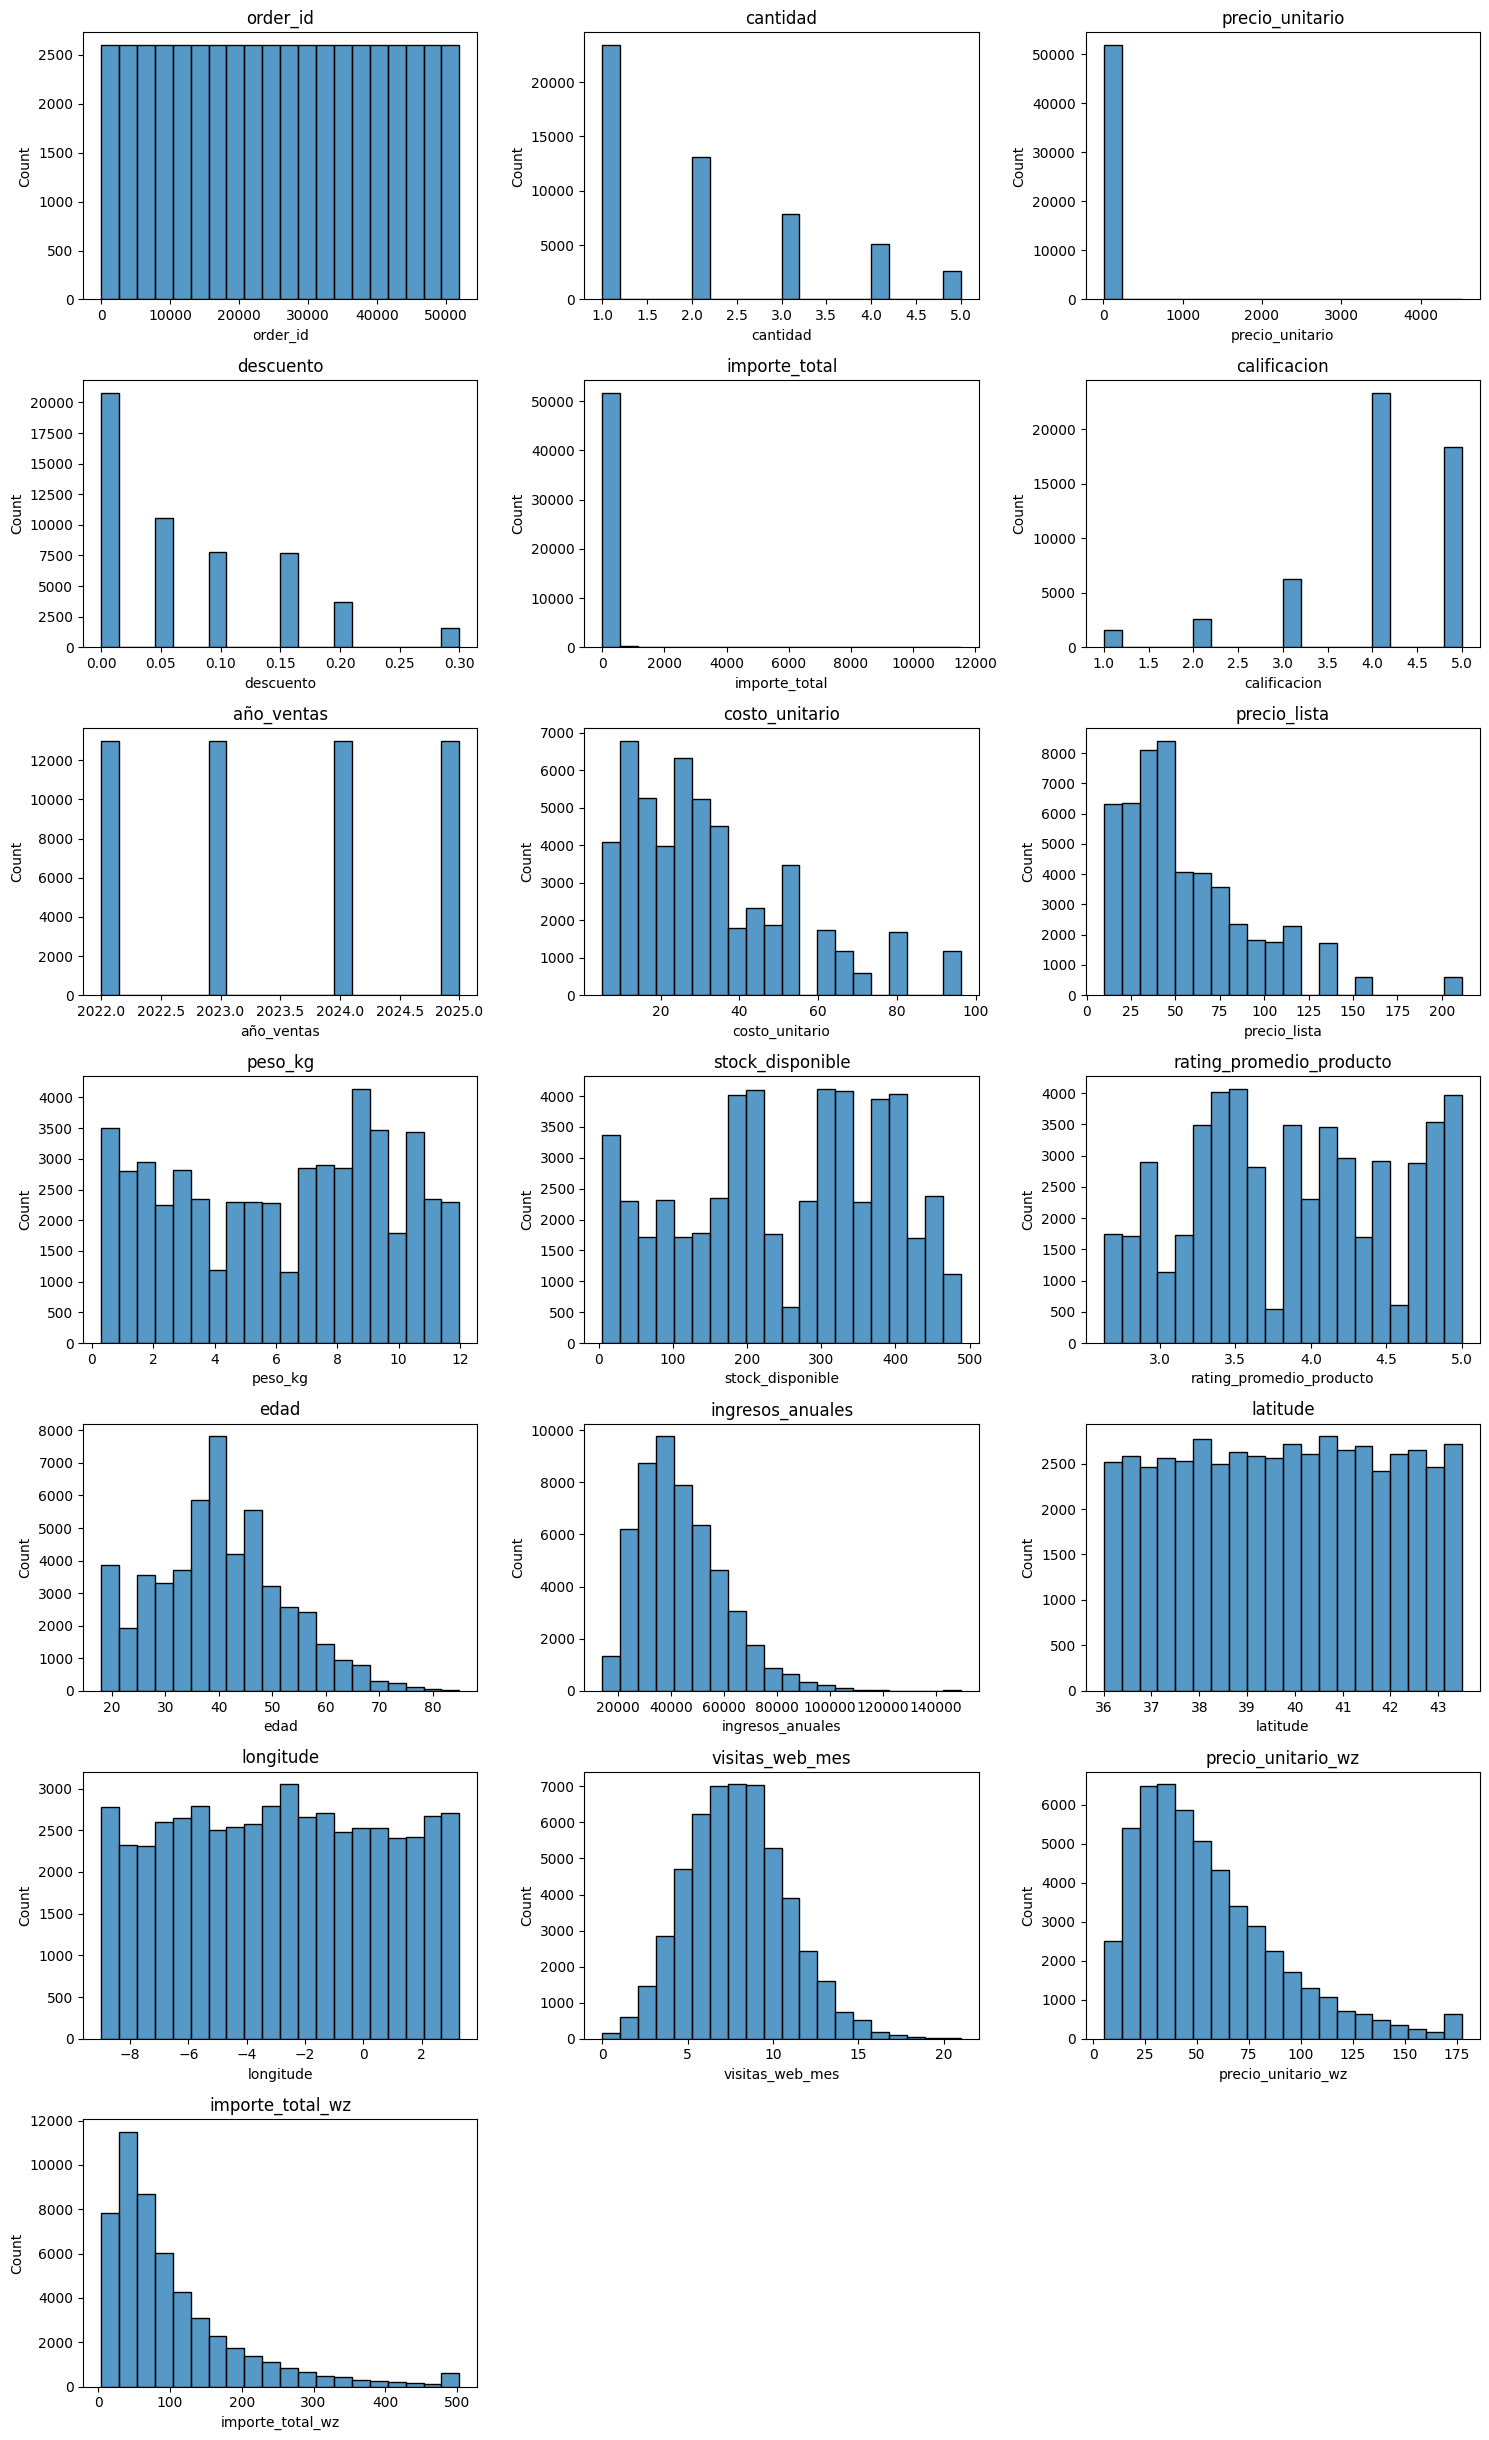


============== BOXPLOTS ==============
(REPRESENTACION DE UNIVARIABLES NUMERICAS - OUTLIERS)


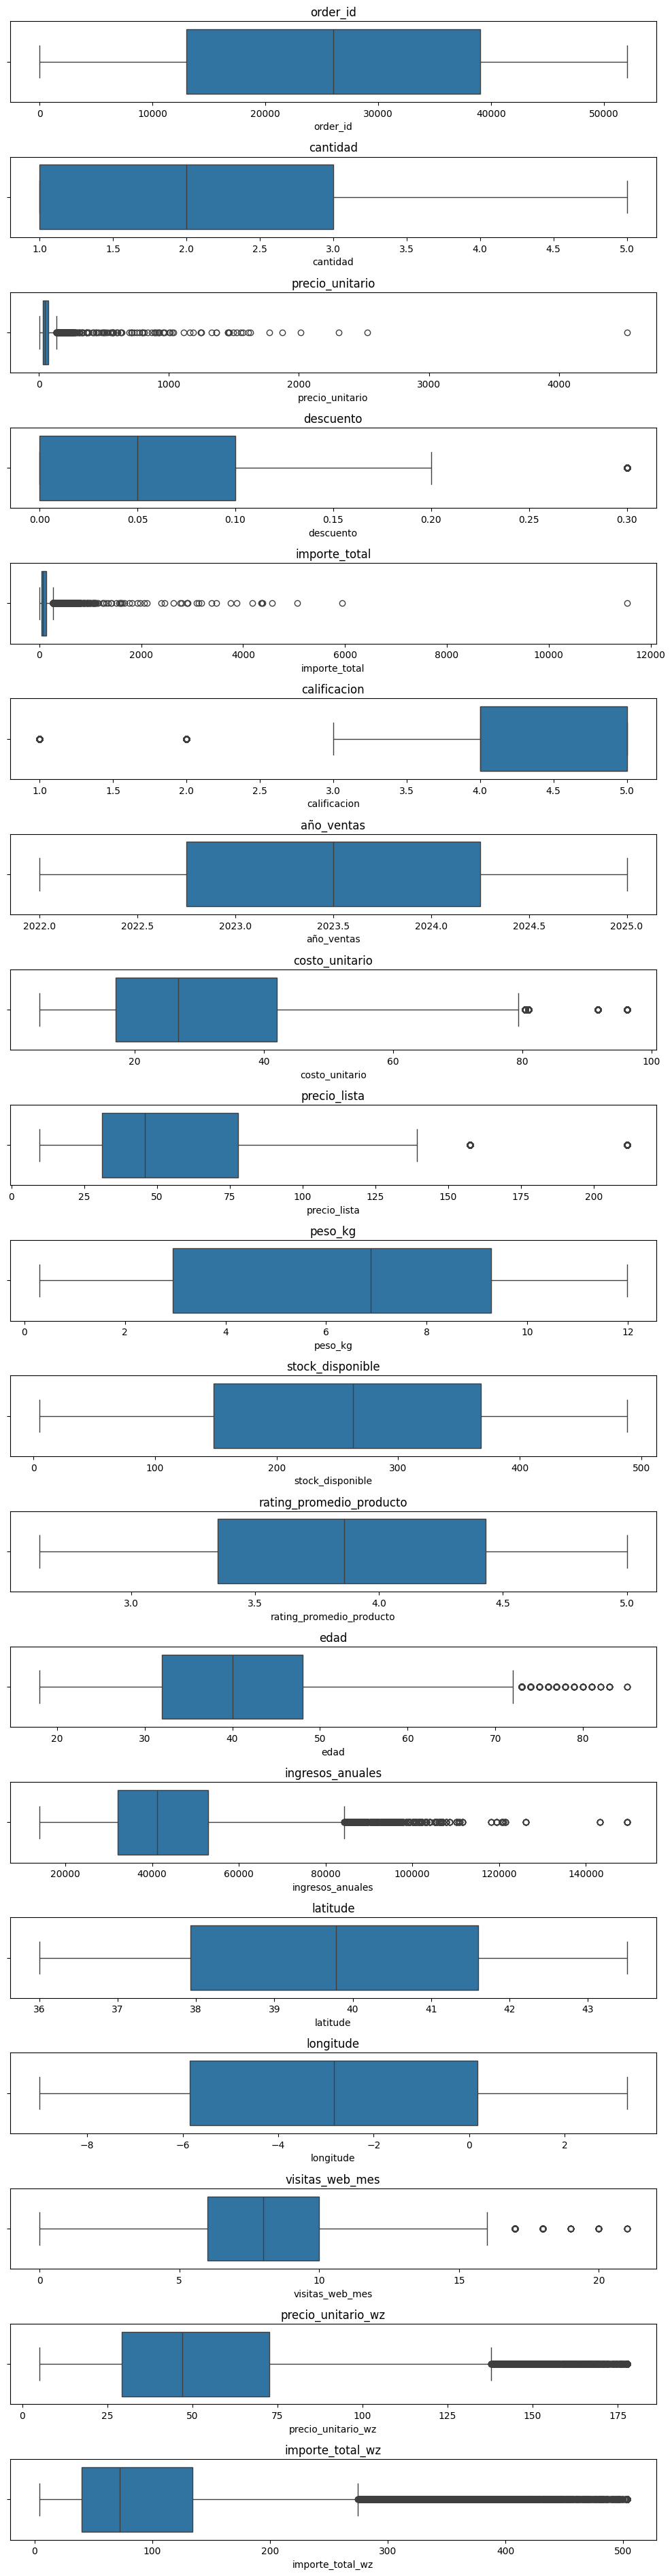

In [7]:
se.eda(df)

In [8]:
cols_excluir = ['order_id', 'id_cliente', 'product_id', 'nombre_producto',
                 'latitude', 'longitude', 'precio_unitario','importe_total ']

VARIABLES NUMERICAS:

 Index(['cantidad', 'descuento', 'importe_total', 'calificacion', 'año_ventas', 'costo_unitario', 'precio_lista', 'peso_kg', 'stock_disponible', 'rating_promedio_producto', 'edad', 'ingresos_anuales', 'visitas_web_mes', 'precio_unitario_wz', 'importe_total_wz'], dtype='str')

VARIABLES CATEGORICAS:

 Index(['metodo_pago', 'envio_gratis', 'devuelto', 'canal', 'categoria_producto', 'marca', 'proveedor', 'estado_civil', 'nivel_educativo', 'tiene_hijos', 'adolescentes_en_casa', 'ciudad', 'region', 'segmento_cliente'], dtype='str')

VARIABLES DATETIME(FECHA):

 Index(['fecha_pedido', 'fecha_lanzamiento', 'fecha_registro'], dtype='str')

========== ESTADÍSTICAS BÁSICAS ==========

VARIABLES NUMERICAS:
                            count      mean       std       min       25%       50%       75%        max
cantidad                  52000.0      2.05      1.20      1.00      1.00      2.00      3.00       5.00
descuento                 52000.0      0.07      0.08      0.00

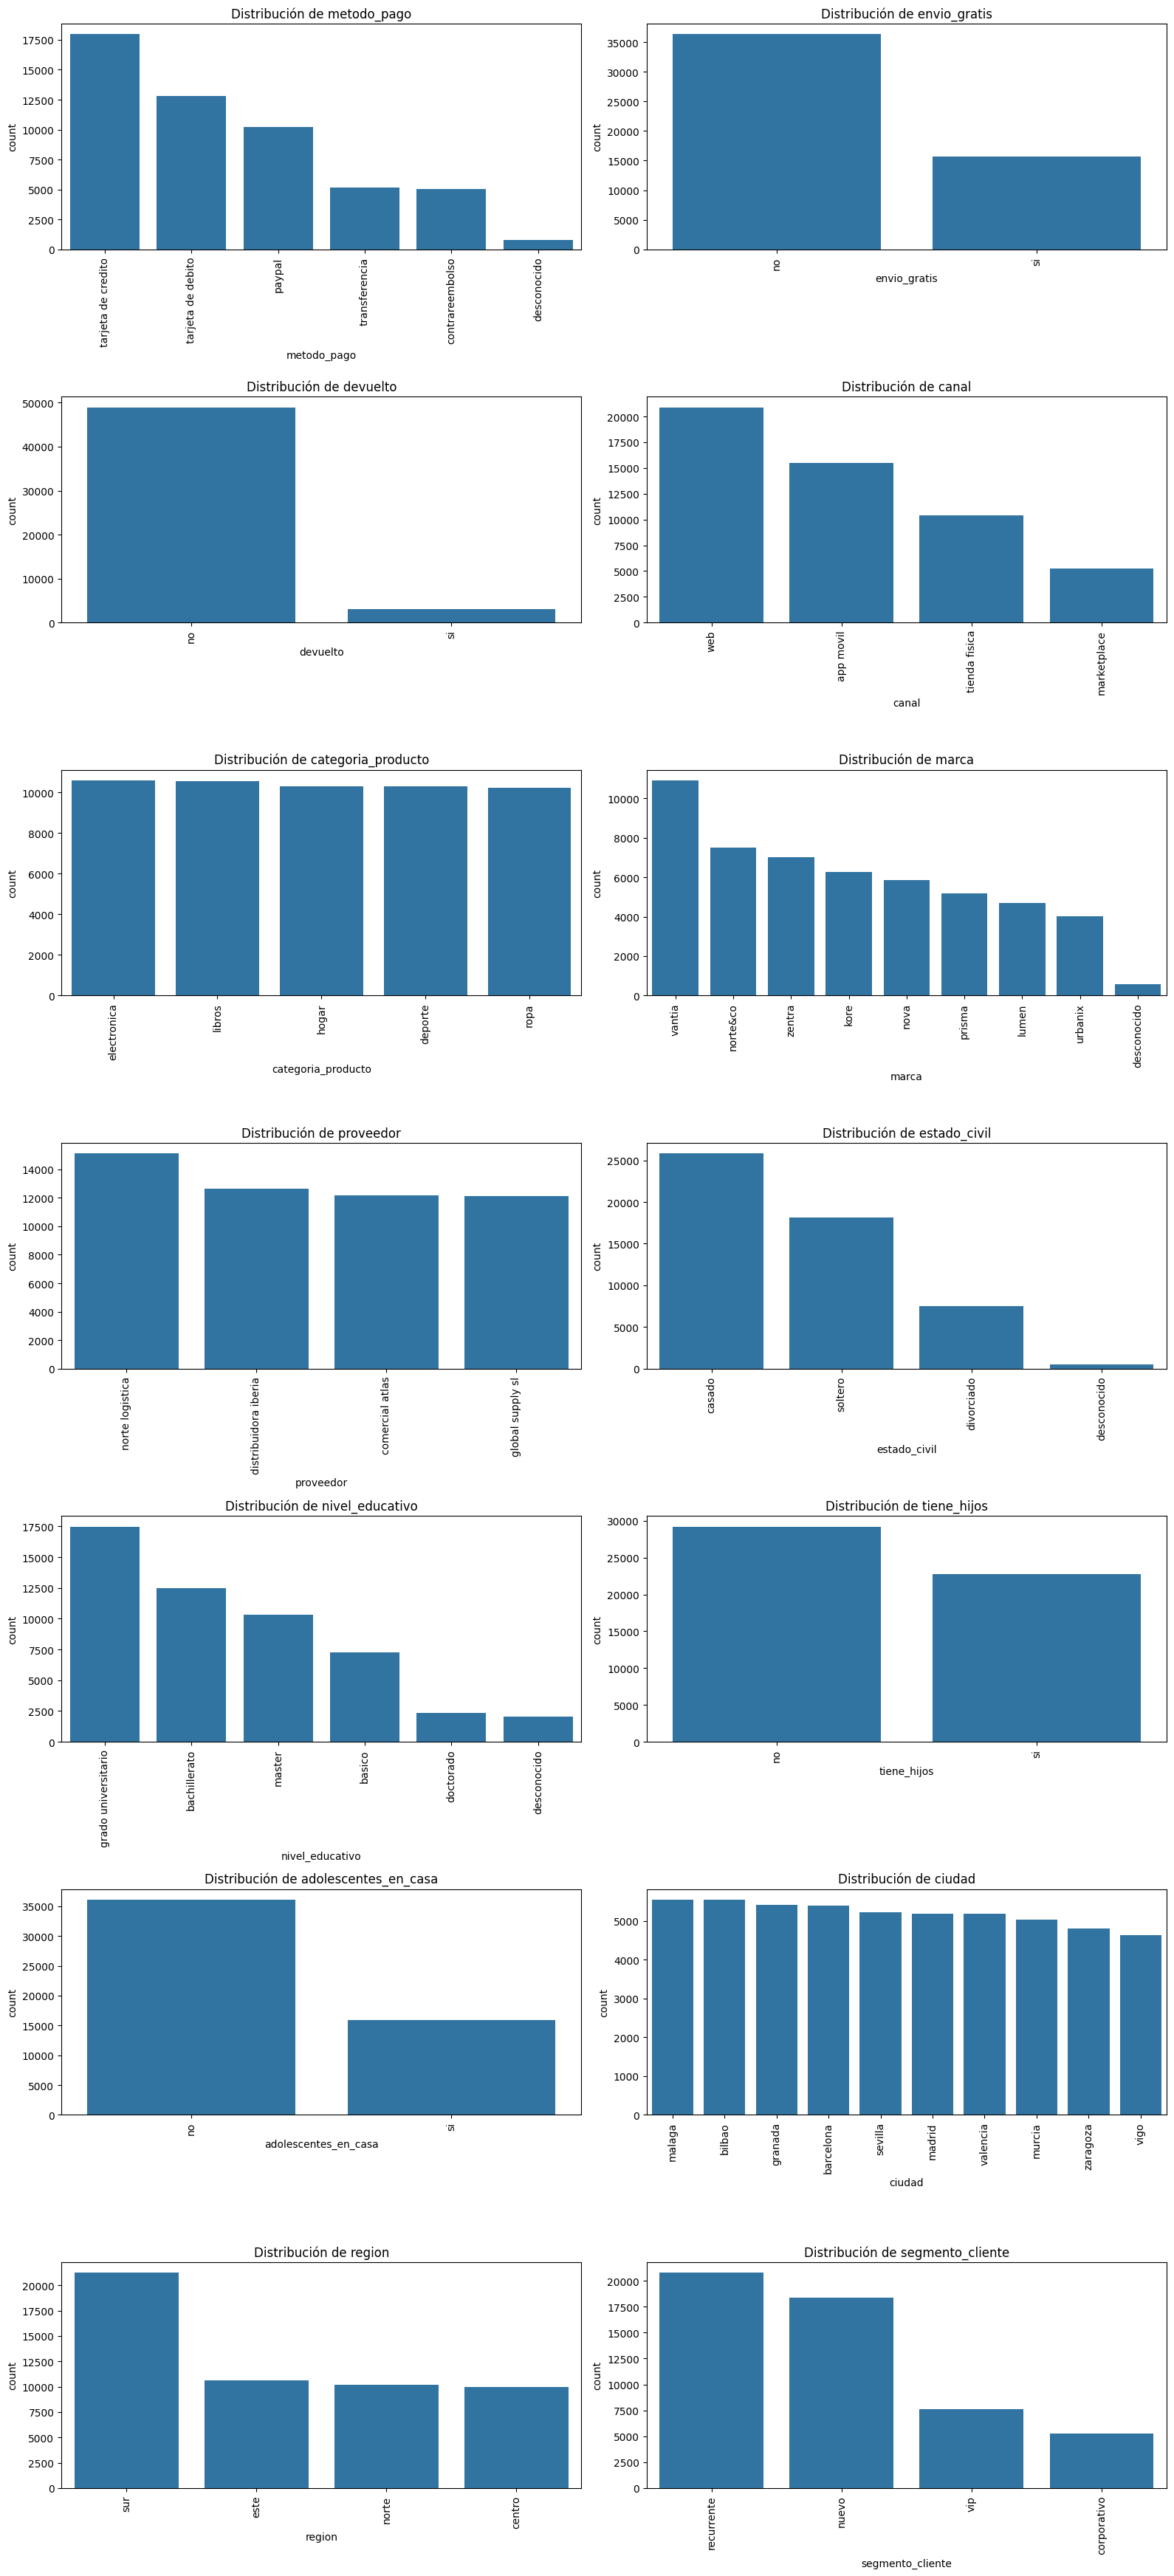


============== HISTOGRAMAS ==============
(REPRESENTACION DE UNIVARIABLES NUMERICAS):


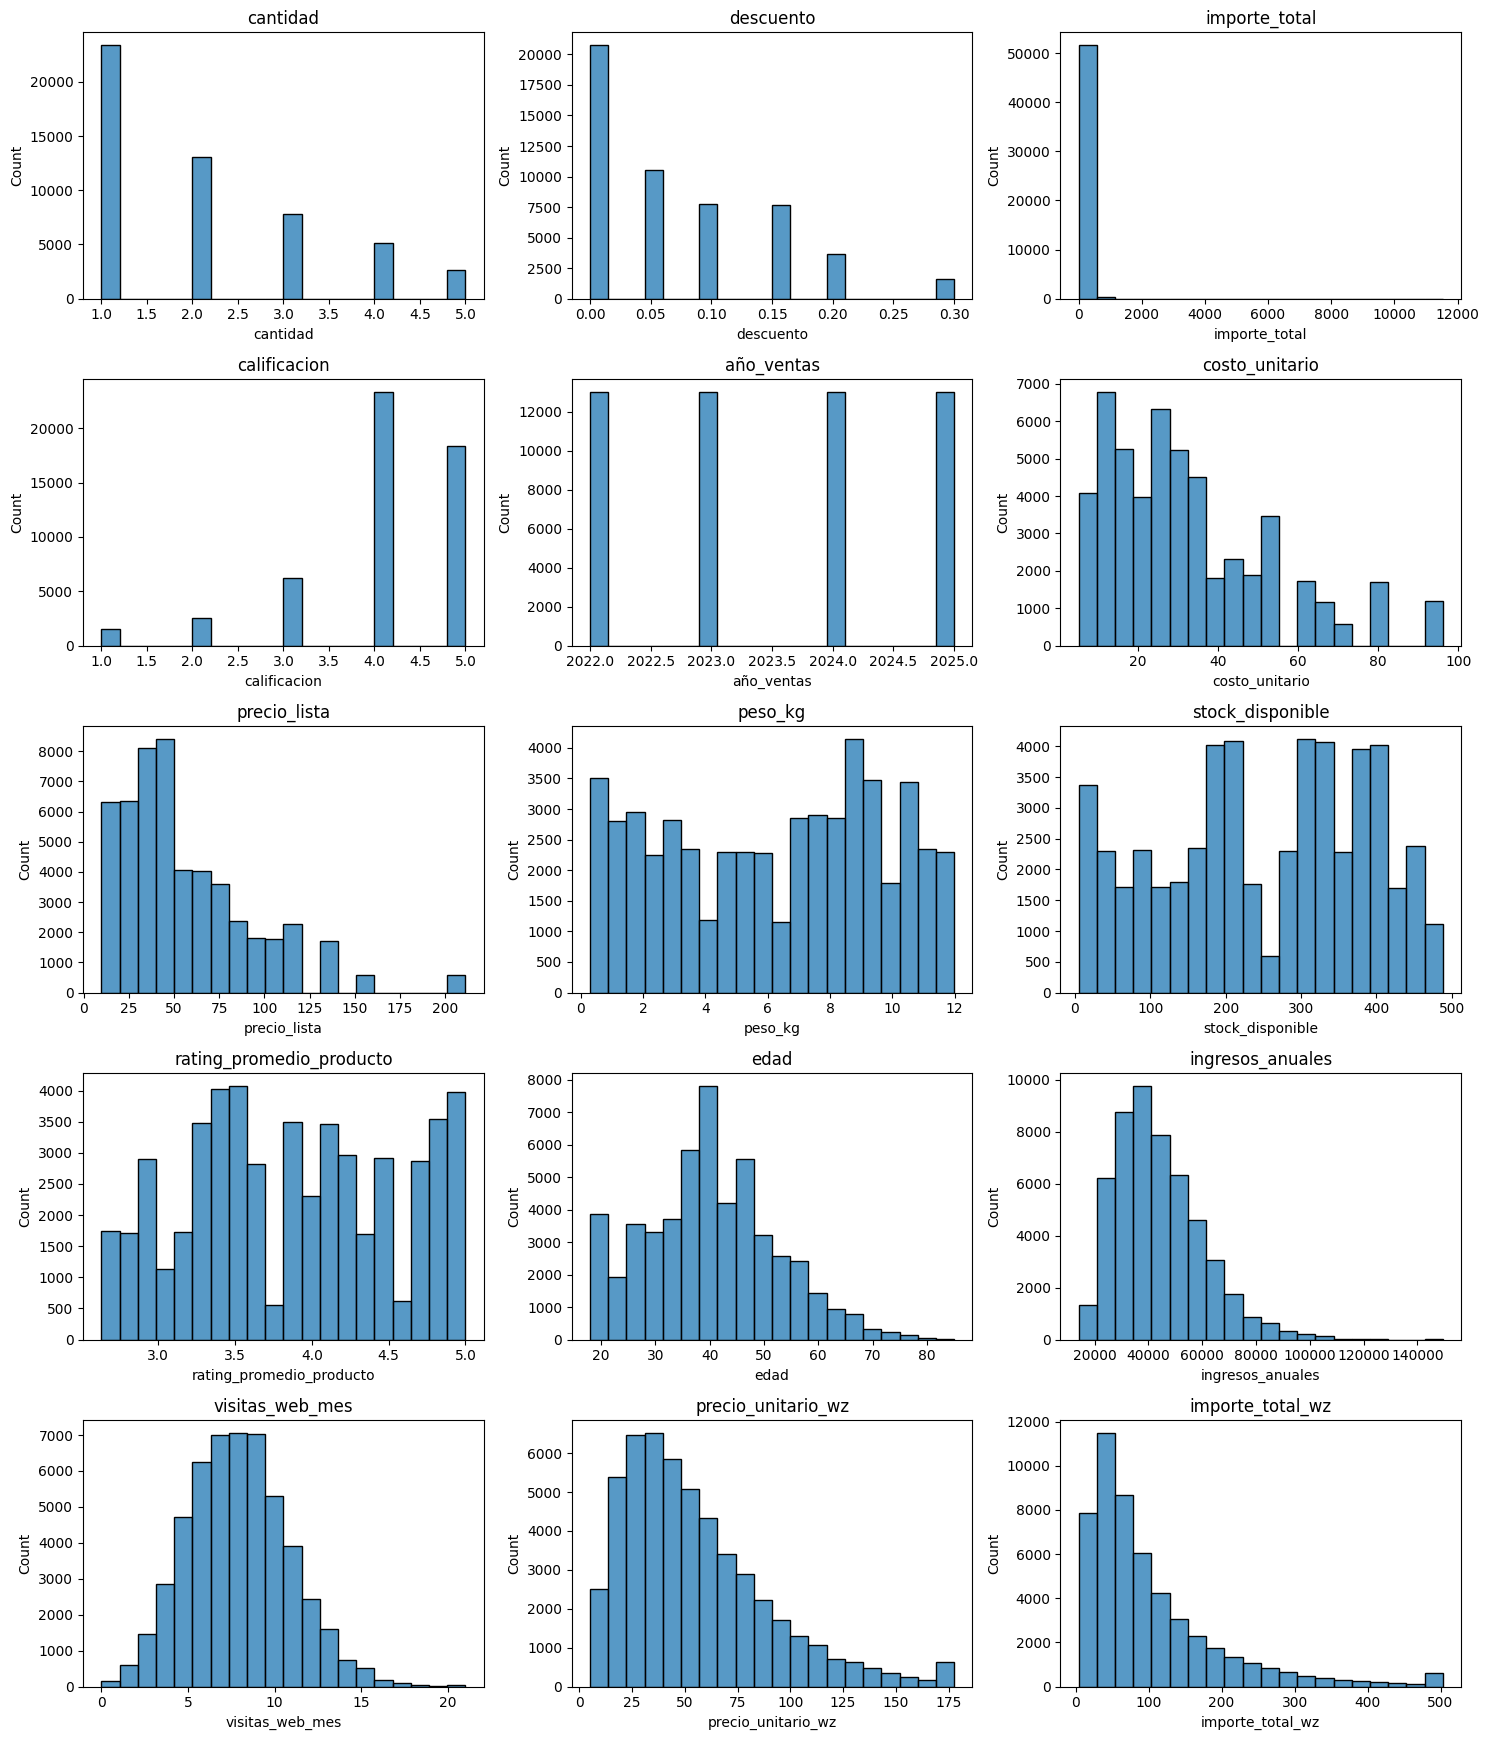


============== BOXPLOTS ==============
(REPRESENTACION DE UNIVARIABLES NUMERICAS - OUTLIERS)


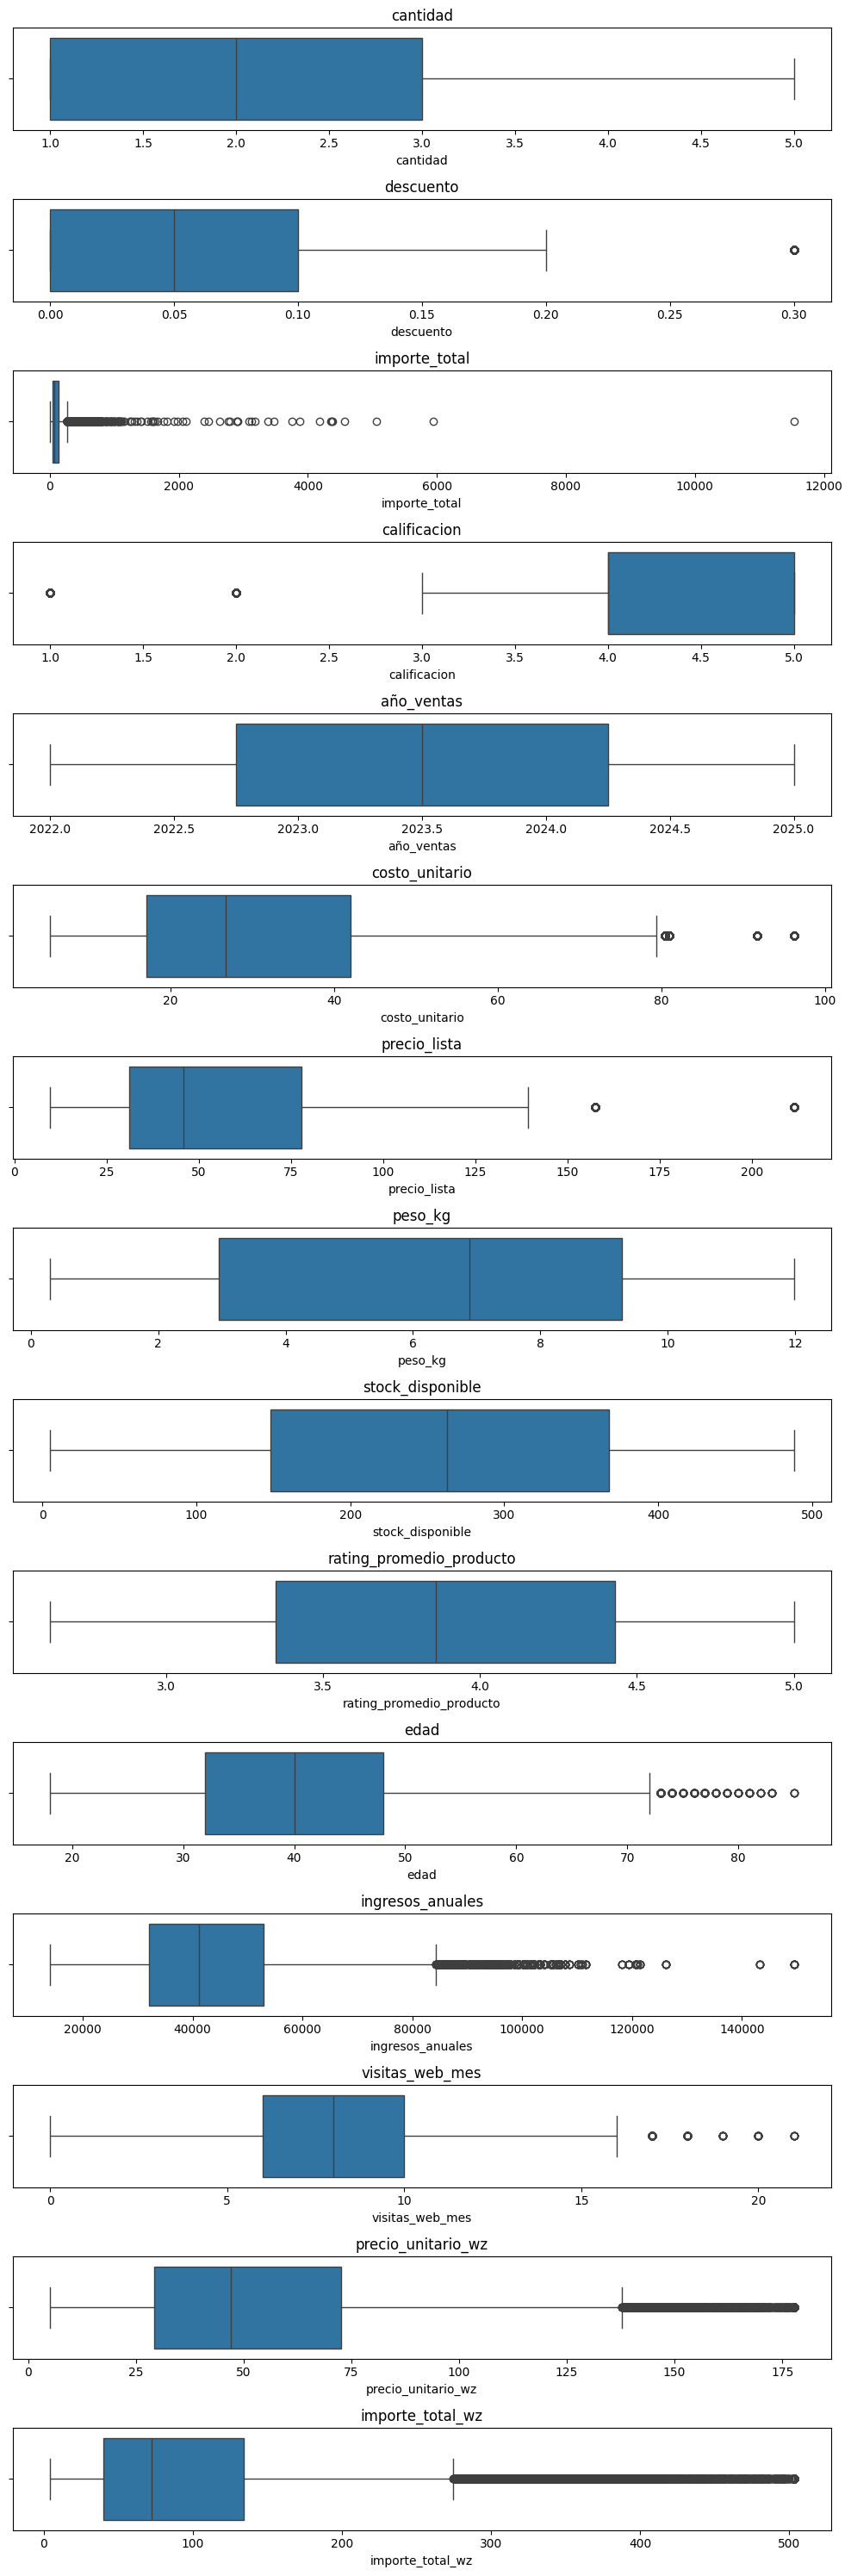

In [9]:
se.eda(df,cols_excluir=cols_excluir)

#### MATRIZ DE CORRELACION

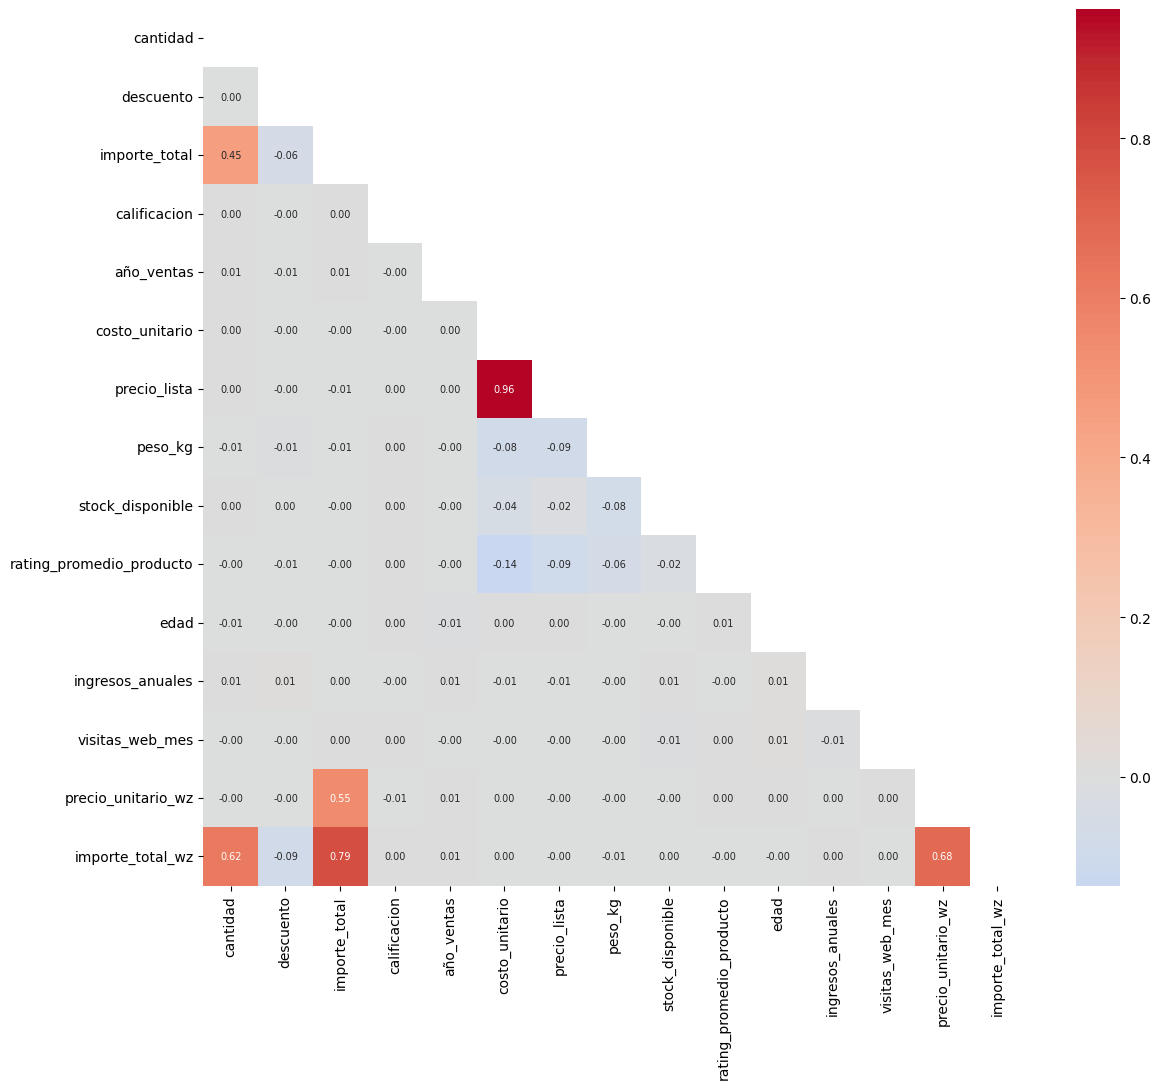

Top 10 pares con mayor correlación (valor absoluto):
precio_lista              costo_unitario              0.961611
importe_total             importe_total_wz            0.785279
importe_total_wz          precio_unitario_wz          0.683578
                          cantidad                    0.618761
importe_total             precio_unitario_wz          0.548456
                          cantidad                    0.452520
rating_promedio_producto  costo_unitario              0.136386
precio_lista              rating_promedio_producto    0.093282
peso_kg                   precio_lista                0.087473
descuento                 importe_total_wz            0.086038
dtype: float64


,cantidad,descuento,importe_total,calificacion,año_ventas,costo_unitario,precio_lista,peso_kg,stock_disponible,rating_promedio_producto,edad,ingresos_anuales,visitas_web_mes,precio_unitario_wz,importe_total_wz
cantidad,1.000000,0.000781,0.452520,0.002524,0.007175,0.002186,0.002015,-0.006401,0.002683,-0.002295,-0.005461,0.008265,-0.001272,-0.001464,0.618761
descuento,0.000781,1.000000,-0.060270,-0.002678,-0.006628,-0.004338,-0.002499,-0.008505,0.000552,-0.007324,-0.000938,0.009475,-0.000737,-0.000098,-0.086038
importe_total,0.452520,-0.060270,1.000000,0.000908,0.007066,-0.004435,-0.005747,-0.007502,-0.004555,-0.000960,-0.000710,0.000199,0.000932,0.548456,0.785279
calificacion,0.002524,-0.002678,0.000908,1.000000,-0.001121,-0.000729,0.000692,0.004128,0.002129,0.003018,0.004603,-0.003231,0.002079,-0.005543,0.000939
año_ventas,0.007175,-0.006628,0.007066,-0.001121,1.000000,0.000101,0.000343,-0.004102,-0.002994,-0.004162,-0.008781,0.005536,-0.002913,0.005062,0.007618
costo_unitario,0.002186,-0.004338,-0.004435,-0.000729,0.000101,1.000000,0.961611,-0.083239,-0.044386,-0.136386,0.004430,-0.005925,-0.003166,0.000271,0.000006
precio_lista,0.002015,-0.002499,-0.005747,0.000692,0.000343,0.961611,1.000000,-0.087473,-0.016748,-0.093282,0.004961,-0.006077,-0.003360,-0.001546,-0.001886
peso_kg,-0.006401,-0.008505,-0.007502,0.004128,-0.004102,-0.083239,-0.087473,1.000000,-0.078744,-0.060227,-0.002048,-0.002061,-0.002150,-0.002454,-0.006885
stock_disponible,0.002683,0.000552,-0.004555,0.002129,-0.002994,-0.044386,-0.016748,-0.078744,1.000000,-0.023955,-0.000673,0.006113,-0.010190,-0.002939,0.000004
rating_promedio_producto,-0.002295,-0.007324,-0.000960,0.003018,-0.004162,-0.136386,-0.093282,-0.060227,-0.023955,1.000000,0.007237,-0.001464,0.001963,0.001921,-0.002012


In [10]:
se.matriz_correlacion(df,cols_excluir=cols_excluir)

## Relaciones cruzadas

In [11]:
df.columns

Index(['order_id', 'id_cliente', 'product_id', 'fecha_pedido', 'cantidad', 'precio_unitario', 'descuento', 'importe_total', 'metodo_pago', 'envio_gratis', 'calificacion', 'devuelto', 'canal', 'año_ventas', 'categoria_producto', 'nombre_producto', 'marca', 'costo_unitario', 'precio_lista', 'peso_kg', 'proveedor', 'stock_disponible', 'fecha_lanzamiento', 'rating_promedio_producto', 'edad', 'estado_civil', 'nivel_educativo', 'ingresos_anuales', 'tiene_hijos', 'adolescentes_en_casa', 'fecha_registro', 'ciudad', 'region', 'latitude', 'longitude', 'segmento_cliente', 'visitas_web_mes', 'precio_unitario_wz', 'importe_total_wz'], dtype='str')

In [12]:
clientes

,id_cliente,n_pedidos,gasto_total,edad,ciudad,segmento_cliente,ingresos_anuales,ticket_medio
0,00047a8c-eaed-4e09-a302-4081b07e37f9,6,582.25,44.0,barcelona,corporativo,41626,97.041667
1,0005530b-bb59-4862-9ed1-9ba4b57e4b95,8,714.03,64.0,granada,recurrente,64957,89.253750
2,000c848f-a5fc-40a5-a3ba-3de5a7e12089,1,9.49,40.0,sevilla,nuevo,37981,9.490000
3,0013343e-3a60-417d-bad5-88780f5a83a1,4,520.32,34.0,murcia,corporativo,61224,130.080000
4,0030dae9-1d2a-4aaf-ba17-c19d34228fbc,3,193.17,48.0,vigo,recurrente,24208,64.390000
...,...,...,...,...,...,...,...,...
7982,ffe3fcfa-07c0-42c4-b97c-52ab6efac87a,1,110.87,22.0,vigo,nuevo,72177,110.870000
7983,ffe5e4a4-9512-4bbd-98f9-75a00a28f4ce,5,648.41,31.0,zaragoza,nuevo,38826,129.682000
7984,ffea67ee-8438-441c-b8a0-5c0ff886b034,3,175.72,47.0,sevilla,nuevo,35518,58.573333
7985,fff01d47-aae0-4ce5-847d-aea0a915c59d,9,546.42,35.0,malaga,recurrente,30258,60.713333


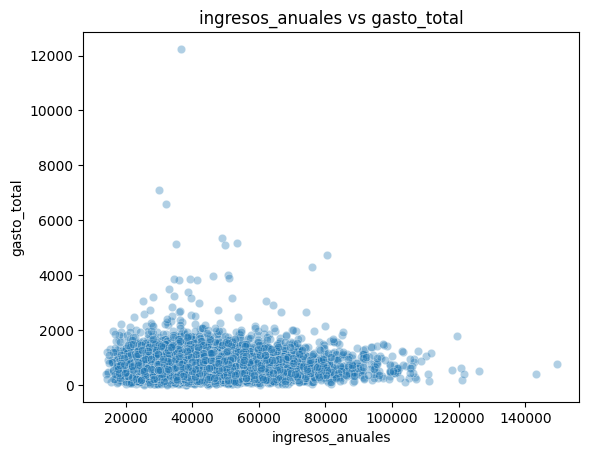

Correlación de Pearson entre ingresos_anuales y gasto_total: -0.0062


np.float64(-0.0062128972867449075)

In [13]:
col_x = 'ingresos_anuales'
col_y = 'gasto_total'
se.bivariante_num_num(clientes,col_x,col_y)

¿Los clientes con mayores ingresos anuales realizan un mayor gasto total?

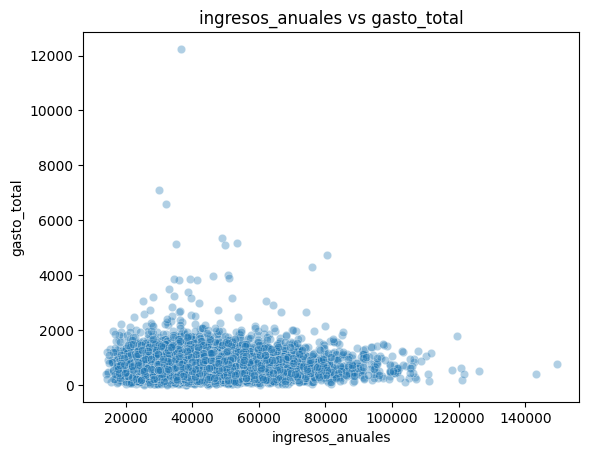

Correlación de Pearson entre ingresos_anuales y gasto_total: -0.0062


np.float64(-0.0062128972867449075)

In [14]:
se.bivariante_num_num(
    clientes,
    "ingresos_anuales",
    "gasto_total"
)

¿Los clientes con mayores ingresos realizan más pedidos?

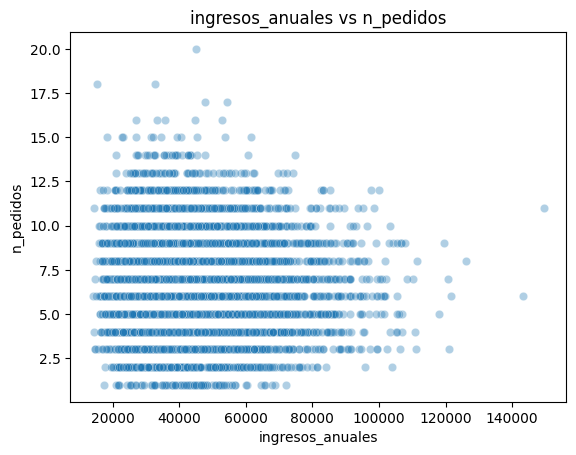

Correlación de Pearson entre ingresos_anuales y n_pedidos: -0.0108


np.float64(-0.01083140780793869)

In [15]:
se.bivariante_num_num(
    clientes,
    "ingresos_anuales",
    "n_pedidos"
)

¿Existe relación entre la edad del cliente y su gasto total?

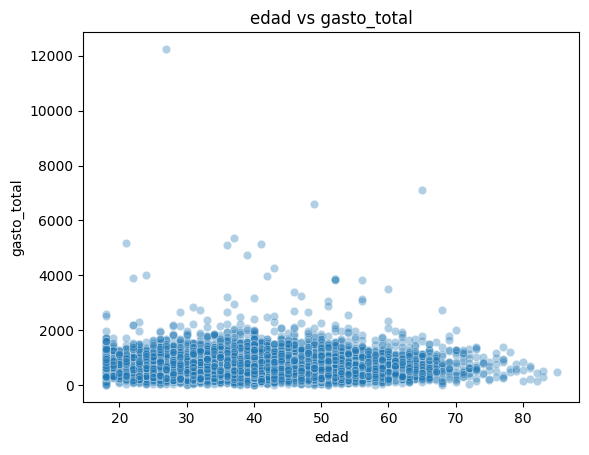

Correlación de Pearson entre edad y gasto_total: -0.0055


np.float64(-0.005485816283443)

In [16]:
se.bivariante_num_num(
    clientes,
    "edad",
    "gasto_total"
)

¿Los clientes que realizan más pedidos son también los que presentan un mayor gasto total?

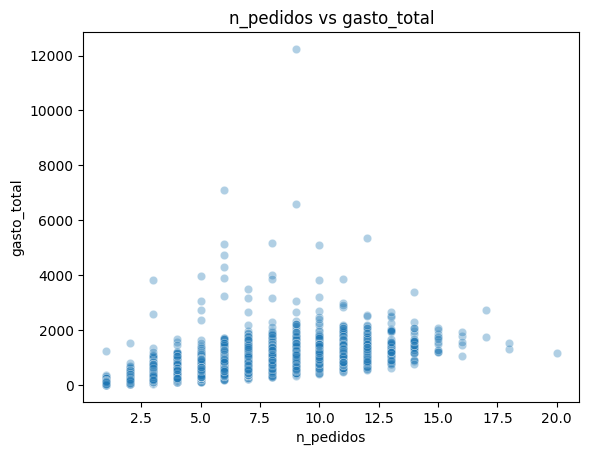

Correlación de Pearson entre n_pedidos y gasto_total: 0.6104


np.float64(0.6104062015583828)

In [17]:
se.bivariante_num_num(
    clientes,
    "n_pedidos",
    "gasto_total"
)

¿Existen diferencias en el gasto total según el segmento de cliente?

¿Qué segmentos realizan más pedidos?

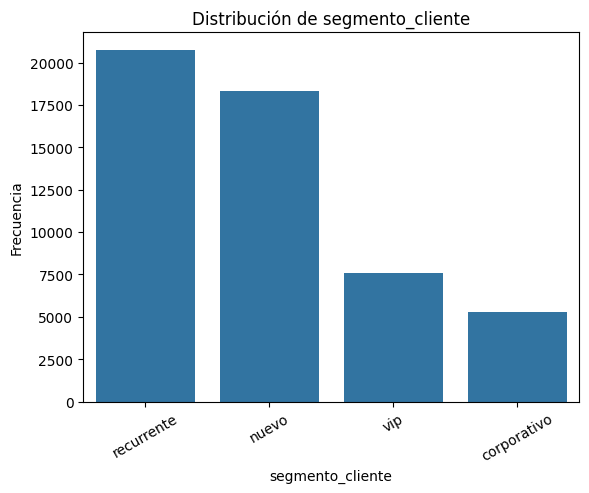

segmento_cliente
recurrente     20768
nuevo          18344
vip             7596
corporativo     5292
Name: count, dtype: int64


In [18]:
se.univariante_categorico(df, col="segmento_cliente")

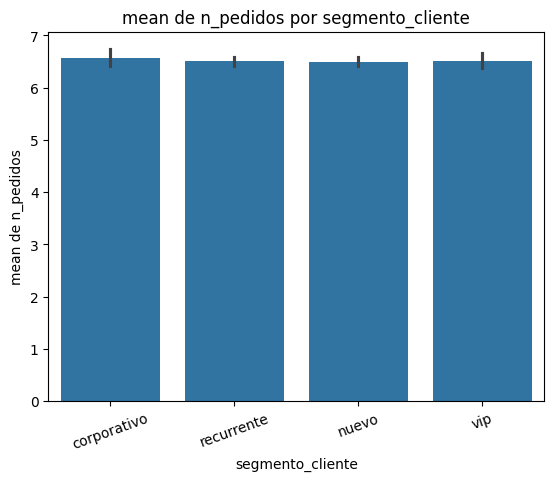

mean de n_pedidos por segmento_cliente:
segmento_cliente
corporativo    6.57
recurrente     6.51
vip            6.51
nuevo          6.50
Name: n_pedidos, dtype: float64


segmento_cliente
corporativo    6.57
recurrente     6.51
vip            6.51
nuevo          6.50
Name: n_pedidos, dtype: float64

In [19]:
se.bivariante_cat_num_bar(clientes, col_cat="segmento_cliente", col_num="n_pedidos")

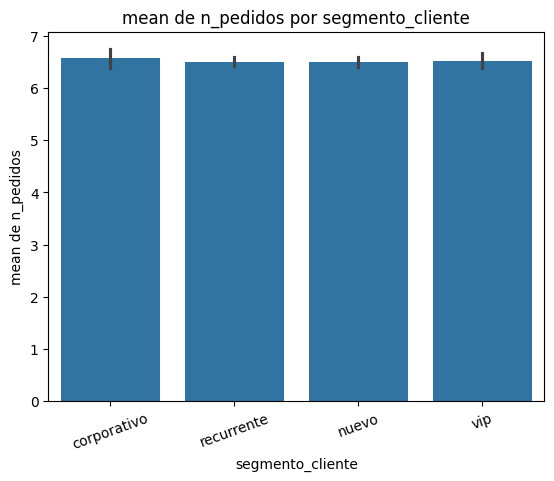

mean de n_pedidos por segmento_cliente:
segmento_cliente
corporativo    6.57
recurrente     6.51
vip            6.51
nuevo          6.50
Name: n_pedidos, dtype: float64


segmento_cliente
corporativo    6.57
recurrente     6.51
vip            6.51
nuevo          6.50
Name: n_pedidos, dtype: float64

In [20]:
se.bivariante_cat_num_bar(clientes, col_cat="segmento_cliente", col_num="n_pedidos")

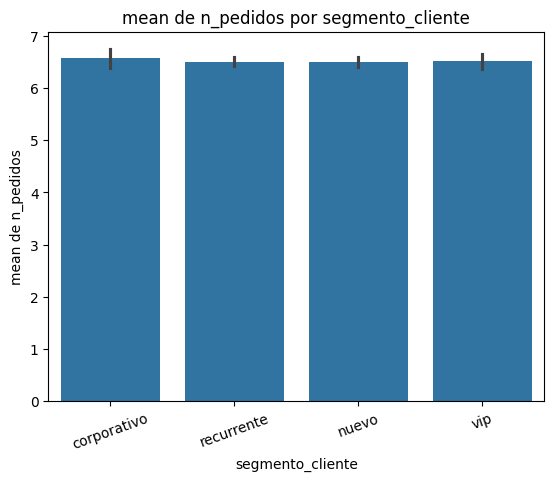

mean de n_pedidos por segmento_cliente:
segmento_cliente
corporativo    6.57
recurrente     6.51
vip            6.51
nuevo          6.50
Name: n_pedidos, dtype: float64


segmento_cliente
corporativo    6.57
recurrente     6.51
vip            6.51
nuevo          6.50
Name: n_pedidos, dtype: float64

In [21]:
se.bivariante_cat_num_bar(clientes, col_cat="segmento_cliente", col_num="n_pedidos")


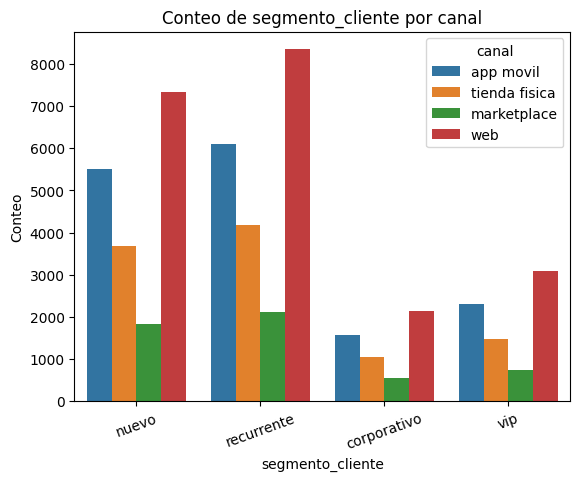

Tabla de conteos: segmento_cliente vs canal
canal             app movil  marketplace  tienda fisica   web
segmento_cliente                                             
corporativo            1572          547           1045  2128
nuevo                  5513         1824           3676  7331
recurrente             6110         2123           4185  8350
vip                    2303          741           1474  3078


canal,app movil,marketplace,tienda fisica,web
segmento_cliente,,,,
corporativo,1572,547,1045,2128
nuevo,5513,1824,3676,7331
recurrente,6110,2123,4185,8350
vip,2303,741,1474,3078


In [22]:
se.bivariante_cat_cat_count(df, col_cat1="segmento_cliente", col_cat2="canal")

si tienes muchas ciudades, el gráfico puede resultar muy cargado.

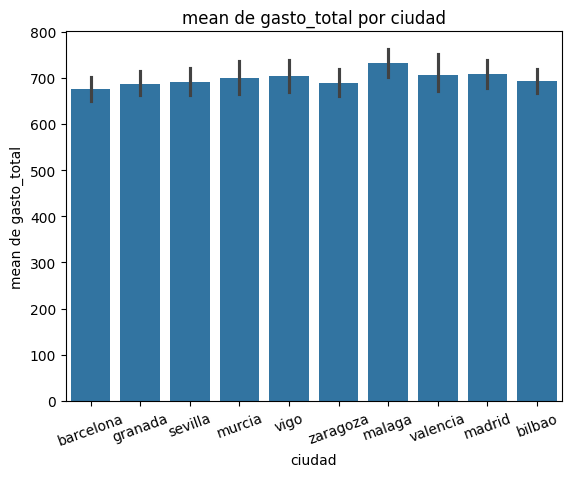

mean de gasto_total por ciudad:
ciudad
malaga       731.23
madrid       708.61
valencia     706.66
vigo         704.29
murcia       699.13
bilbao       693.28
sevilla      690.55
zaragoza     689.19
granada      687.25
barcelona    675.16
Name: gasto_total, dtype: float64


ciudad
malaga       731.23
madrid       708.61
valencia     706.66
vigo         704.29
murcia       699.13
bilbao       693.28
sevilla      690.55
zaragoza     689.19
granada      687.25
barcelona    675.16
Name: gasto_total, dtype: float64

In [23]:
se.bivariante_cat_num_bar(
    clientes,
    col_cat="ciudad",
    col_num="gasto_total"
)

estudiar comportamiento geográfico.

In [24]:
def bivariante_cat_num_bar(df, col_cat, col_num, estimator="mean", errorbar=None):
    """
    Estadístico (media, mediana, suma...) de una variable numérica
    según una variable categórica.
    Dibuja un barplot con ese estadístico.

    estimator: "mean", "median", "sum", etc.
    """
    sns.barplot(data=df, x=col_cat, y=col_num, estimator=estimator)
    plt.title(f"{estimator} de {col_num} por {col_cat}")
    plt.xlabel(col_cat)
    plt.ylabel(f"{estimator} de {col_num}")
    plt.xticks(rotation=20)
    plt.show()

    valores = df.groupby(col_cat)[col_num].agg(estimator).round(2).sort_values(ascending=False)
    print(f"{estimator} de {col_num} por {col_cat}:")
    print(valores)

    return valores

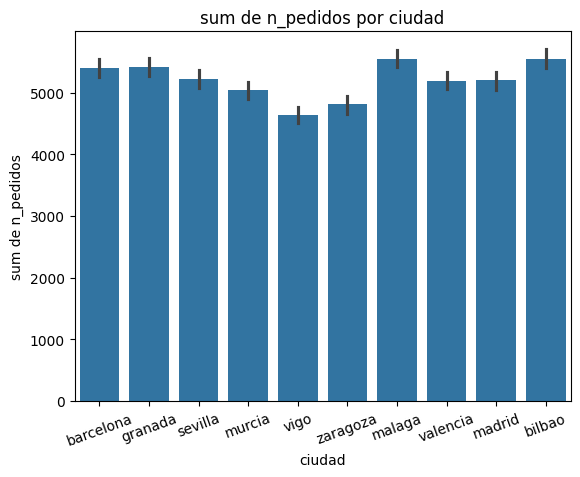

sum de n_pedidos por ciudad:
ciudad
malaga       5550
bilbao       5543
granada      5412
barcelona    5398
sevilla      5226
madrid       5195
valencia     5191
murcia       5041
zaragoza     4806
vigo         4638
Name: n_pedidos, dtype: int64


ciudad
malaga       5550
bilbao       5543
granada      5412
barcelona    5398
sevilla      5226
madrid       5195
valencia     5191
murcia       5041
zaragoza     4806
vigo         4638
Name: n_pedidos, dtype: int64

In [25]:
se.bivariante_cat_num_bar(
    clientes,
    col_cat="ciudad",
    col_num="n_pedidos",
    estimator="sum"
)

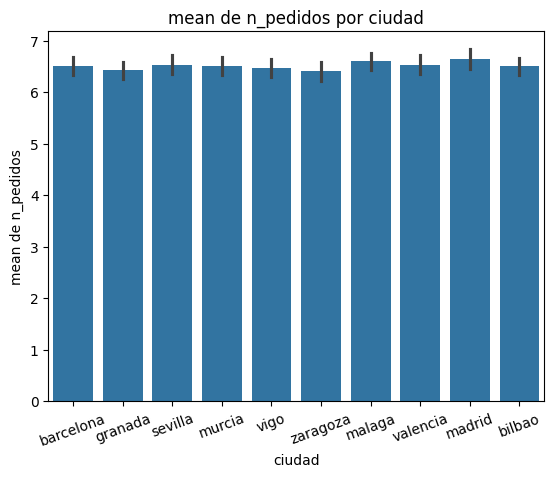

mean de n_pedidos por ciudad:
ciudad
madrid       6.64
malaga       6.60
sevilla      6.53
valencia     6.53
barcelona    6.51
bilbao       6.50
murcia       6.50
vigo         6.47
granada      6.42
zaragoza     6.40
Name: n_pedidos, dtype: float64


ciudad
madrid       6.64
malaga       6.60
sevilla      6.53
valencia     6.53
barcelona    6.51
bilbao       6.50
murcia       6.50
vigo         6.47
granada      6.42
zaragoza     6.40
Name: n_pedidos, dtype: float64

In [26]:
se.bivariante_cat_num_bar(
    clientes,
    col_cat="ciudad",
    col_num="n_pedidos"
)

In [27]:
clientes.groupby("ciudad")["n_pedidos"].sum().sort_values(ascending=False)

ciudad
malaga       5550
bilbao       5543
granada      5412
barcelona    5398
sevilla      5226
madrid       5195
valencia     5191
murcia       5041
zaragoza     4806
vigo         4638
Name: n_pedidos, dtype: int64

<Axes: xlabel='segmento_cliente', ylabel='count'>

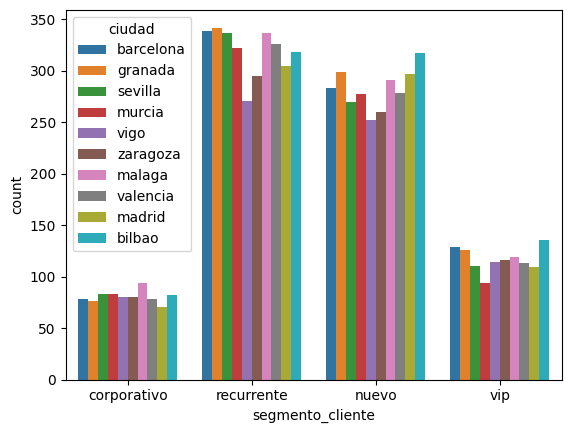

In [28]:
sns.countplot(
    data=clientes,
    x="segmento_cliente",
    hue="ciudad"
)

¿Los clientes con mayores ingresos realizan compras de mayor importe medio?

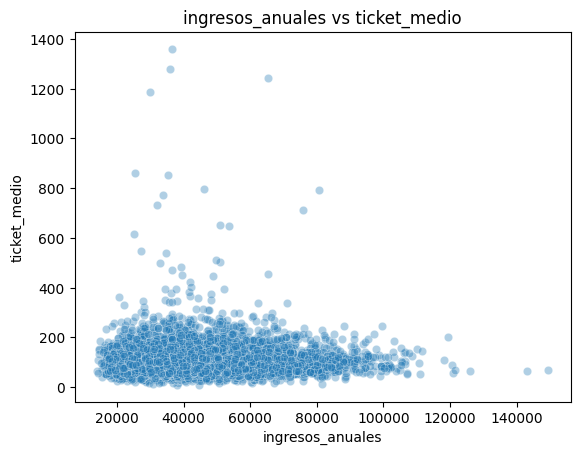

Correlación de Pearson entre ingresos_anuales y ticket_medio: 0.0001


np.float64(0.000128014175926956)

In [29]:
se.bivariante_num_num(
    clientes,
    "ingresos_anuales",
    "ticket_medio"
)

ticket medio por pedido

In [30]:
clientes["ticket_medio"] = (
    clientes["gasto_total"] / clientes["n_pedidos"]
)

¿Existe relación entre la edad del cliente y el valor medio de sus pedidos?

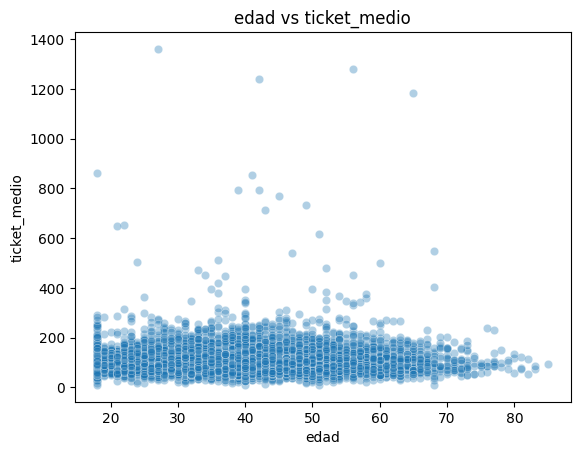

Correlación de Pearson entre edad y ticket_medio: 0.0020


np.float64(0.0019578050796821324)

In [31]:
se.bivariante_num_num(
    clientes,
    "edad",
    "ticket_medio"
)

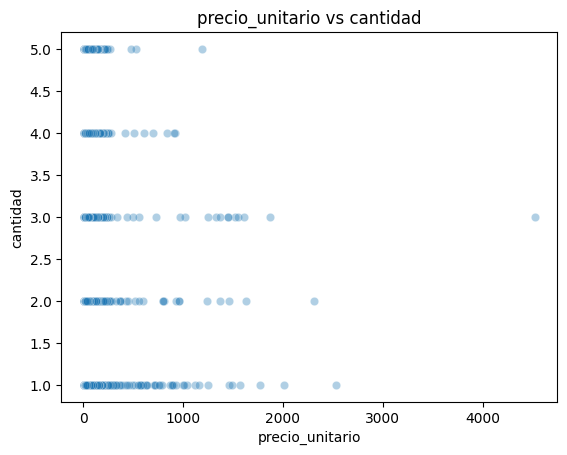

Correlación de Pearson entre precio_unitario y cantidad: -0.0012


np.float64(-0.0012448617579919959)

In [32]:
se.bivariante_num_num(df, col_x="precio_unitario", col_y="cantidad")

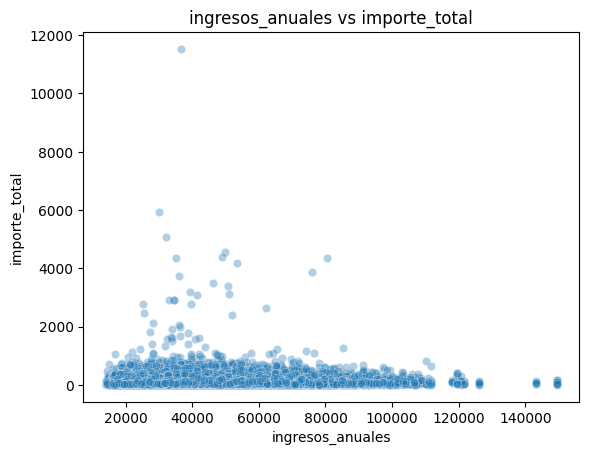

Correlación de Pearson entre ingresos_anuales y importe_total: 0.0002


np.float64(0.00019899663493100616)

In [33]:
se.bivariante_num_num(df, col_x="ingresos_anuales", col_y="importe_total")


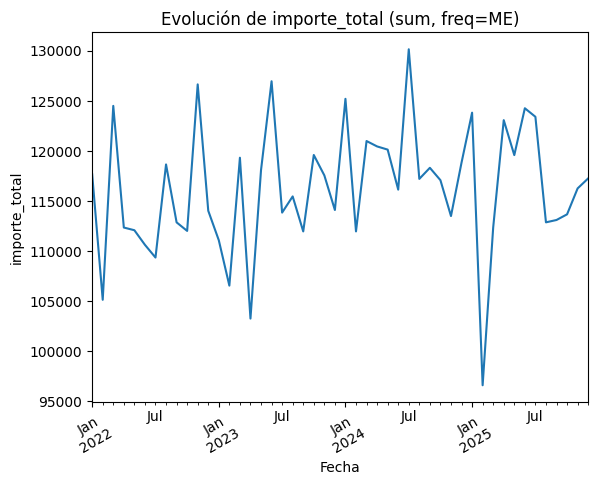

Media: 116225.72   Std: 6427.28
Mínimo: 2025-02-28 00:00:00 -> 96573.55
Máximo: 2024-07-31 00:00:00 -> 130132.57


fecha_pedido
2022-01-31    117646.63
2022-02-28    105109.72
2022-03-31    124478.22
2022-04-30    112327.57
2022-05-31    112058.10
2022-06-30    110600.78
2022-07-31    109330.67
2022-08-31    118628.87
2022-09-30    112844.67
2022-10-31    111990.55
2022-11-30    126625.46
2022-12-31    114003.78
2023-01-31    111055.20
2023-02-28    106526.65
2023-03-31    119301.30
2023-04-30    103234.65
2023-05-31    118060.49
2023-06-30    126937.94
2023-07-31    113819.25
2023-08-31    115436.45
2023-09-30    111938.51
2023-10-31    119573.18
2023-11-30    117536.70
2023-12-31    114077.69
2024-01-31    125183.14
2024-02-29    111940.51
2024-03-31    120966.78
2024-04-30    120428.22
2024-05-31    120110.09
2024-06-30    116115.44
2024-07-31    130132.57
2024-08-31    117185.21
2024-09-30    118292.79
2024-10-31    117057.20
2024-11-30    113475.03
2024-12-31    118810.72
2025-01-31    123799.19
2025-02-28     96573.55
2025-03-31    112331.92
2025-04-30    123054.24
2025-05-31    119561.72
202

In [35]:
se.bivariante_temporal(df, col_fecha="fecha_pedido", col_num="importe_total", freq="ME", agg="sum")


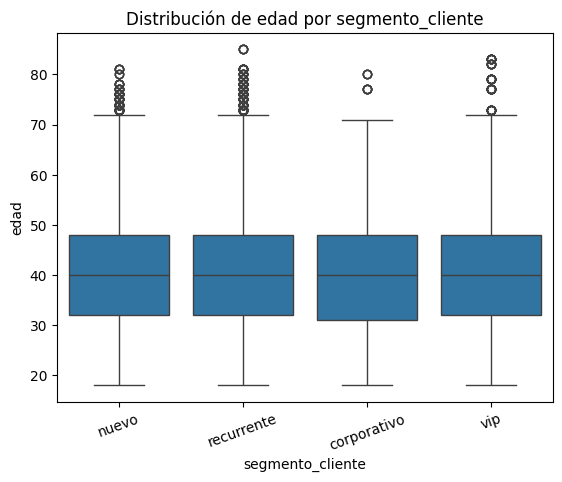

Resumen de edad por segmento_cliente:
                    count   mean    std   min   25%   50%   75%   max
segmento_cliente                                                     
corporativo        5292.0  39.65  12.09  18.0  31.0  40.0  48.0  80.0
nuevo             18344.0  40.30  11.88  18.0  32.0  40.0  48.0  81.0
recurrente        20768.0  40.09  12.37  18.0  32.0  40.0  48.0  85.0
vip                7596.0  40.25  12.21  18.0  32.0  40.0  48.0  83.0


,count,mean,std,min,25%,50%,75%,max
segmento_cliente,,,,,,,,
corporativo,5292.0,39.65,12.09,18.0,31.0,40.0,48.0,80.0
nuevo,18344.0,40.30,11.88,18.0,32.0,40.0,48.0,81.0
recurrente,20768.0,40.09,12.37,18.0,32.0,40.0,48.0,85.0
vip,7596.0,40.25,12.21,18.0,32.0,40.0,48.0,83.0


In [47]:
se.bivariante_cat_num_box(
    df,
    col_cat="segmento_cliente",
    col_num="edad"
)

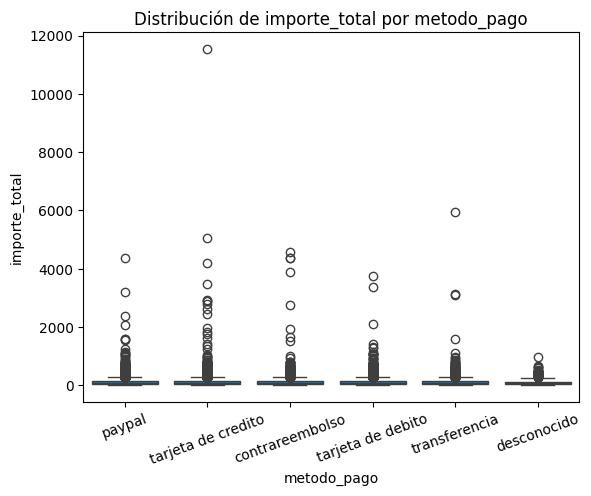

Resumen de importe_total por metodo_pago:
                      count    mean     std   min    25%    50%     75%       max
metodo_pago                                                                      
contrareembolso      5031.0  109.96  163.81  5.26  39.92  73.03  134.00   4562.93
desconocido           780.0  105.83  102.04  5.26  40.22  72.30  130.38    980.73
paypal              10219.0  106.52  121.62  4.56  39.97  71.94  132.86   4354.49
tarjeta de credito  17964.0  107.36  152.95  4.22  39.86  72.14  134.47  11531.82
tarjeta de debito   12825.0  106.33  113.32  4.67  40.31  73.01  133.99   3753.47
transferencia        5181.0  108.52  144.80  4.40  40.19  72.45  134.05   5944.66


,count,mean,std,min,25%,50%,75%,max
metodo_pago,,,,,,,,
contrareembolso,5031.0,109.96,163.81,5.26,39.92,73.03,134.00,4562.93
desconocido,780.0,105.83,102.04,5.26,40.22,72.30,130.38,980.73
paypal,10219.0,106.52,121.62,4.56,39.97,71.94,132.86,4354.49
tarjeta de credito,17964.0,107.36,152.95,4.22,39.86,72.14,134.47,11531.82
tarjeta de debito,12825.0,106.33,113.32,4.67,40.31,73.01,133.99,3753.47
transferencia,5181.0,108.52,144.80,4.40,40.19,72.45,134.05,5944.66


In [48]:
se.bivariante_cat_num_box(
    df,
    col_cat="metodo_pago",
    col_num="importe_total", 
)

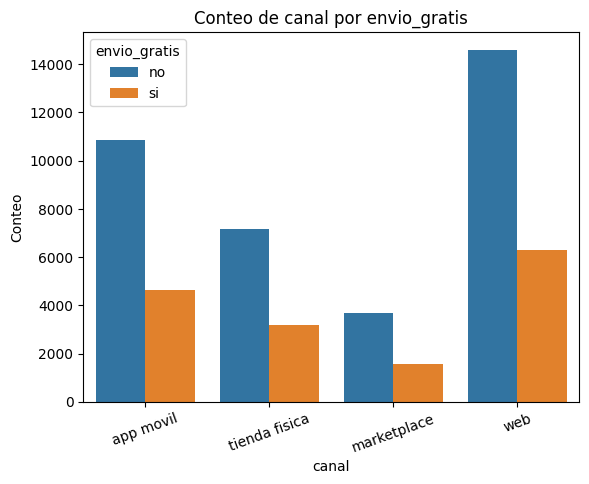

Tabla de conteos: canal vs envio_gratis
envio_gratis      no    si
canal                     
app movil      10877  4621
marketplace     3671  1564
tienda fisica   7187  3193
web            14598  6289


envio_gratis,no,si
canal,,
app movil,10877,4621
marketplace,3671,1564
tienda fisica,7187,3193
web,14598,6289


In [38]:
se.bivariante_cat_cat_count(df, col_cat1="canal", col_cat2="envio_gratis")

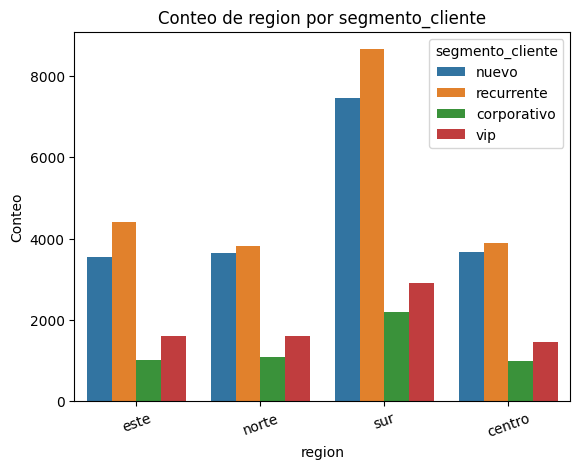

Tabla de conteos: region vs segmento_cliente
segmento_cliente  corporativo  nuevo  recurrente   vip
region                                                
centro                    985   3668        3893  1455
este                     1021   3549        4405  1614
norte                    1098   3657        3814  1612
sur                      2188   7470        8656  2915


segmento_cliente,corporativo,nuevo,recurrente,vip
region,,,,
centro,985,3668,3893,1455
este,1021,3549,4405,1614
norte,1098,3657,3814,1612
sur,2188,7470,8656,2915


In [40]:
se.bivariante_cat_cat_count(df, col_cat1="region", col_cat2="segmento_cliente")

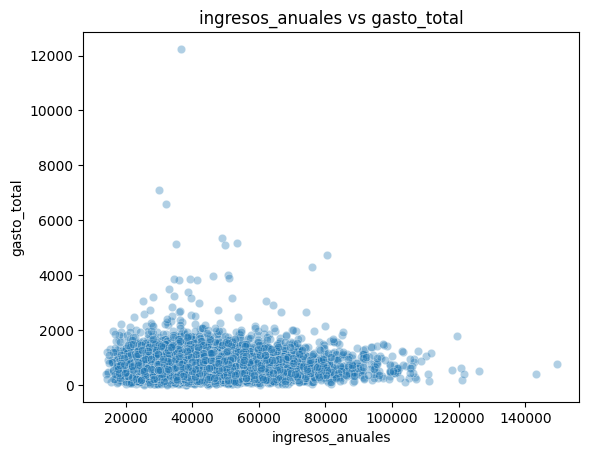

Correlación de Pearson entre ingresos_anuales y gasto_total: -0.0062


np.float64(-0.0062128972867449075)

In [41]:
se.bivariante_num_num(clientes, col_x="ingresos_anuales", col_y="gasto_total")

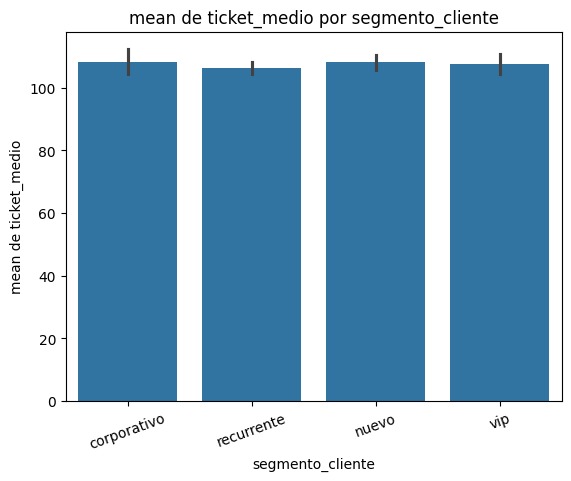

mean de ticket_medio por segmento_cliente:
segmento_cliente
corporativo    108.15
nuevo          108.01
vip            107.55
recurrente     106.12
Name: ticket_medio, dtype: float64


segmento_cliente
corporativo    108.15
nuevo          108.01
vip            107.55
recurrente     106.12
Name: ticket_medio, dtype: float64

In [44]:
se.bivariante_cat_num_bar(clientes, col_cat="segmento_cliente", col_num="ticket_medio")


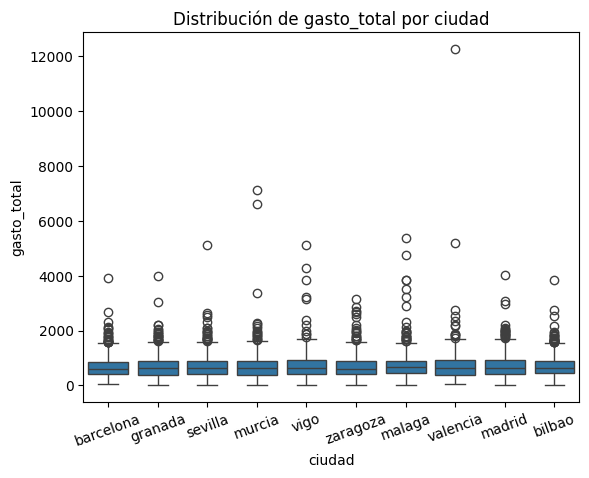

Resumen de gasto_total por ciudad:
           count    mean     std    min     25%     50%     75%       max
ciudad                                                                   
barcelona  829.0  675.16  386.99  52.47  409.18  597.98  869.35   3908.77
bilbao     853.0  693.28  383.80  33.25  437.15  634.98  884.02   3856.45
granada    843.0  687.25  402.56   9.96  399.27  618.78  885.36   3976.89
madrid     782.0  708.61  426.70  18.49  415.88  624.69  929.95   4024.84
malaga     841.0  731.23  472.36  32.69  443.50  665.53  907.44   5360.47
murcia     776.0  699.13  500.64  21.69  397.04  622.93  902.75   7112.34
sevilla    800.0  690.55  419.16   9.49  404.11  634.53  884.04   5127.14
valencia   795.0  706.66  582.25  43.70  398.80  619.92  925.25  12247.02
vigo       717.0  704.29  462.35  14.72  406.38  640.92  925.81   5112.10
zaragoza   751.0  689.19  414.32  19.47  405.85  616.02  896.14   3164.69


,count,mean,std,min,25%,50%,75%,max
ciudad,,,,,,,,
barcelona,829.0,675.16,386.99,52.47,409.18,597.98,869.35,3908.77
bilbao,853.0,693.28,383.80,33.25,437.15,634.98,884.02,3856.45
granada,843.0,687.25,402.56,9.96,399.27,618.78,885.36,3976.89
madrid,782.0,708.61,426.70,18.49,415.88,624.69,929.95,4024.84
malaga,841.0,731.23,472.36,32.69,443.50,665.53,907.44,5360.47
murcia,776.0,699.13,500.64,21.69,397.04,622.93,902.75,7112.34
sevilla,800.0,690.55,419.16,9.49,404.11,634.53,884.04,5127.14
valencia,795.0,706.66,582.25,43.70,398.80,619.92,925.25,12247.02
vigo,717.0,704.29,462.35,14.72,406.38,640.92,925.81,5112.10


In [45]:
se.bivariante_cat_num_box(clientes, col_cat="ciudad", col_num="gasto_total")